Catherine Carmosino

11/20/2025

This code follows the steps taken in [decoupler Single-cell Enrichment Analysis](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_sc.html#)

# Loading in the Data

In [1]:
#the package imports we need for single-cell enrichment analysis using decoupler
import hisepy
import scanpy as sc
import decoupler as dc


/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


In [2]:
#importing the data file
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [3]:
#creating a list
adata_list = []

#looping through the file names
for h5ad_file in h5ad_files:
    #read the file into an AnnData object using scanpy
    adata = sc.read_h5ad(h5ad_file)
    #appending the AnnData file into the list
    adata_list.append(adata)

In [4]:
#concatenating/combining all of the AnnData objects into one
adata = sc.concat(adata_list)

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [5]:
adata

AnnData object with n_obs × n_vars = 450000 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    obsm: 'X_pca', 'X_umap'

In [51]:
#looking at the observations in adata
adata.obs

,original_barcodes,batch_id,pool_id,chip_id,well_id,n_umis,n_genes,plate_location,cyto_treatment,drug_treatment,...,drug_mw,drug_solvent,drug_pathway,drug_target,drug_description,drug_chembl_name,drug_chembl_id,AIFI_L1,AIFI_L2,leiden_2
barcodes,,,,,,,,,,,,,,,,,,,,,
c83df837-3e10-4e8a-9329-68b7fc9a4cc7,ACCGCCATCAACCGCTACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W1,1827.0,490,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD4 Central Memory,19
445c57f1-bc42-40cb-a2c3-859baf98794c,TCCCGCAAGTAATGGCACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W1,989.0,370,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD8 Naive,8
6a5bc577-b17e-492d-af15-6ae76aff2c4f,ATGGGTTAGGGTTGCAACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W2,1976.0,532,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD4 Central Memory,6
293648fb-97f6-4937-9594-91eeb7fdf58d,CCCGTAGTCTGGAAACACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W2,846.0,370,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD4 Central Memory,3
33df20df-bf79-43ab-a9b4-02c9c97c89ad,ACACTAAAGTGTGCAGACAACCAGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W3,1299.0,422,F9,IL-6,A8247,...,485.94,DMSO,JAK/STAT Signaling,EGFR,Irreversible EGFR/HER2 inhibitor,AFATINIB,CHEMBL1173655,T cell,CD4 Central Memory,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2f3f3b7e-c7d8-4318-a014-92388b889c4e,GATGGACGTAACTAGGTGGATCTGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W4,1291.0,408,D5,IL-6,A4138,...,312.37,DMSO,Chromatin/Epigenetics,JAK,Janus kinase inhibitor,TOFACITINIB,CHEMBL221959,T cell,CD4 Central Memory,10
90977027-a8bb-4d08-83de-bdb16264d4af,TGAATCTTCACGTTATTGGATCTGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W1,881.0,360,D5,IL-6,A4138,...,312.37,DMSO,Chromatin/Epigenetics,JAK,Janus kinase inhibitor,TOFACITINIB,CHEMBL221959,T cell,CD4 Central Memory,5
ac0541a6-aefa-4d36-8c7e-97d80ef707e8,CTATGGGAGTGCCCTGTGGATCTGGT-1,EXP-01608,EXP-01608_PA,EXP-01608_PAC1,EXP-01608_PAC1W3,1243.0,374,D5,IL-6,A4138,...,312.37,DMSO,Chromatin/Epigenetics,JAK,Janus kinase inhibitor,TOFACITINIB,CHEMBL221959,T cell,CD8 Naive,3


### Visualization of whole dataset

... storing 'drug_cas_number' as categorical
... storing 'drug_description' as categorical
... storing 'drug_chembl_name' as categorical
... storing 'drug_chembl_id' as categorical


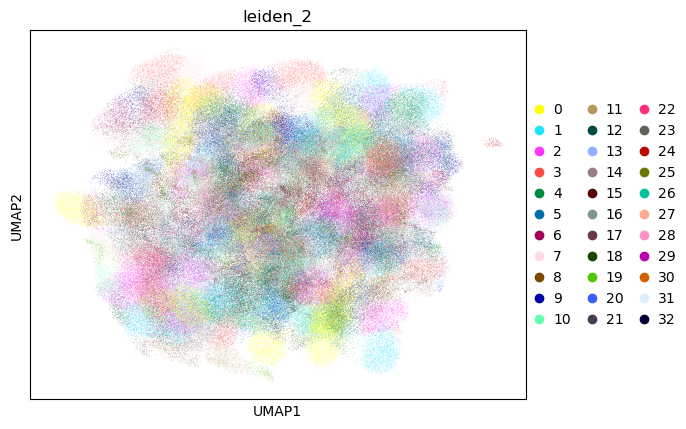

In [7]:
sc.pl.umap(
    adata=adata,
    color="leiden_2",
)

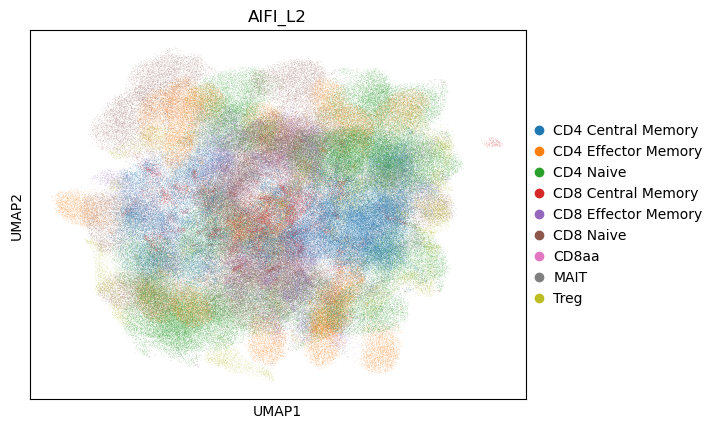

In [8]:
sc.pl.umap(
    adata=adata,
    color="AIFI_L2",
)

# Enrichment analysis

## Cell Type Scoring

### Marker Genes

In [52]:
#loading in marker genes from the PanglaoDB database 
#it compiles and annotates cell type markers across multiple tissues
markers = dc.op.resource("PanglaoDB", organism="human")
markers

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
0,A1CF,False,Hepatocytes,Endoderm,True,0.189189,0.004437,True,0.175000,0.000257,9606,Liver,0.002
1,A2APA5,False,Germ cells,Mesoderm,False,0.000000,0.000000,True,0.432927,0.000000,10090,Reproductive,0.004
2,A2M,True,Bergmann glia,Ectoderm,True,0.000000,0.062343,True,0.333333,0.001604,9606,Brain,0.012
3,A3FIN4,False,Mast cells,Mesoderm,False,0.000000,0.000000,True,0.184211,0.000708,10090,Immune system,0.001
4,A4GALT,True,Mast cells,Mesoderm,True,0.000000,0.014133,True,0.000000,0.003023,9606,Immune system,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8206,ZNF521,False,Adipocyte progenitor cells,Mesoderm,True,0.000000,0.010338,False,0.000000,0.000000,9606,Connective tissue,0.002
8207,ZNRF4,False,Germ cells,Mesoderm,True,0.284360,0.000000,True,0.000000,0.000000,9606,Reproductive,0.010
8208,ZPBP2,True,Germ cells,Mesoderm,True,0.436019,0.000000,True,0.000000,0.000000,9606,Reproductive,0.008


Canonical markers are genes whose expression is considered the standard for a given cell type. Want to filter for when those rows are True.

In [53]:
#filtering for certain aspects
markers = markers[
    #want human = True
    markers["human"].astype(bool)
    #want canonical marker = True
    & markers["canonical_marker"].astype(bool)
    #want higher human sensitivity
    & (markers["human_sensitivity"].astype(float) > 0.5)
]
markers

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
18,ABCA3,True,Pulmonary alveolar type II cells,Endoderm,True,0.692308,0.000944,True,0.007576,0.000518,9606,Lungs,0.001
90,ACSL5,True,Enterocytes,Endoderm,True,0.666667,0.015380,True,0.728477,0.050121,9606,GI tract,0.055
105,ACTA2,True,Smooth muscle cells,Mesoderm,True,0.904762,0.013560,True,1.000000,0.031363,9606,Smooth muscle,0.035
113,ACTG2,True,Smooth muscle cells,Mesoderm,True,0.523810,0.017345,True,0.314050,0.007178,9606,Smooth muscle,0.011
114,ACTG2,True,Myoepithelial cells,Mesoderm,True,1.000000,0.019755,True,0.716667,0.006828,9606,Smooth muscle,0.011
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8092,VWF,True,Endothelial cells,Mesoderm,True,0.711538,0.003562,True,0.000000,0.000000,9606,Vasculature,0.016
8101,WFDC2,True,Luminal epithelial cells,Ectoderm,True,0.733333,0.091281,True,0.000000,0.000000,9606,Mammary gland,0.056
8102,WFDC2,True,Ductal cells,Endoderm,True,0.685714,0.087742,True,0.000000,0.000000,9606,Pancreas,0.056


In [54]:
# remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]
markers


,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
18,ABCA3,True,Pulmonary alveolar type II cells,Endoderm,True,0.692308,0.000944,True,0.007576,0.000518,9606,Lungs,0.001
90,ACSL5,True,Enterocytes,Endoderm,True,0.666667,0.015380,True,0.728477,0.050121,9606,GI tract,0.055
105,ACTA2,True,Smooth muscle cells,Mesoderm,True,0.904762,0.013560,True,1.000000,0.031363,9606,Smooth muscle,0.035
113,ACTG2,True,Smooth muscle cells,Mesoderm,True,0.523810,0.017345,True,0.314050,0.007178,9606,Smooth muscle,0.011
114,ACTG2,True,Myoepithelial cells,Mesoderm,True,1.000000,0.019755,True,0.716667,0.006828,9606,Smooth muscle,0.011
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8092,VWF,True,Endothelial cells,Mesoderm,True,0.711538,0.003562,True,0.000000,0.000000,9606,Vasculature,0.016
8101,WFDC2,True,Luminal epithelial cells,Ectoderm,True,0.733333,0.091281,True,0.000000,0.000000,9606,Mammary gland,0.056
8102,WFDC2,True,Ductal cells,Endoderm,True,0.685714,0.087742,True,0.000000,0.000000,9606,Pancreas,0.056


**Looks like it removed 1 row that was a duplicate (before there were 691 rows, after there wer 690).**

In [56]:
#this is how to filter for only Immune system cells?? do we want to do this....?
markers["organ"].unique()
markers[markers["organ"] == "Immune system"]

,target,canonical_marker,source,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
255,AIF1,True,Macrophages,Mesoderm,True,0.916667,0.127987,True,0.826263,0.051822,9606,Immune system,0.085
256,AIF1,True,Dendritic cells,Mesoderm,True,0.884354,0.094581,True,0.880952,0.074246,9606,Immune system,0.085
374,ANXA1,True,Dendritic cells,Mesoderm,True,0.748299,0.341215,True,0.476190,0.118060,9606,Immune system,0.161
634,BANK1,True,B cells naive,Mesoderm,True,0.533333,0.005980,True,0.000000,0.005133,9606,Immune system,0.006
655,BCL11A,True,Plasmacytoid dendritic cells,Mesoderm,True,0.909091,0.107886,True,1.000000,0.141535,9606,Immune system,0.134
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7965,TYROBP,True,Macrophages,Mesoderm,True,1.000000,0.139623,True,0.000000,0.000000,9606,Immune system,0.149
8064,VPREB3,True,B cells naive,Mesoderm,True,0.533333,0.014479,True,0.000000,0.000000,9606,Immune system,0.011
8065,VPREB3,True,B cells,Mesoderm,True,0.629032,0.004792,True,0.000000,0.000000,9606,Immune system,0.011


In [57]:
#renaming cell columns
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers

,target,canonical_marker,source,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
18,ABCA3,True,Pulmonary alveolar type II cells,Endoderm,True,0.692308,0.000944,True,0.007576,0.000518,9606,Lungs,0.001
90,ACSL5,True,Enterocytes,Endoderm,True,0.666667,0.015380,True,0.728477,0.050121,9606,GI tract,0.055
105,ACTA2,True,Smooth muscle cells,Mesoderm,True,0.904762,0.013560,True,1.000000,0.031363,9606,Smooth muscle,0.035
113,ACTG2,True,Smooth muscle cells,Mesoderm,True,0.523810,0.017345,True,0.314050,0.007178,9606,Smooth muscle,0.011
114,ACTG2,True,Myoepithelial cells,Mesoderm,True,1.000000,0.019755,True,0.716667,0.006828,9606,Smooth muscle,0.011
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8092,VWF,True,Endothelial cells,Mesoderm,True,0.711538,0.003562,True,0.000000,0.000000,9606,Vasculature,0.016
8101,WFDC2,True,Luminal epithelial cells,Ectoderm,True,0.733333,0.091281,True,0.000000,0.000000,9606,Mammary gland,0.056
8102,WFDC2,True,Ductal cells,Endoderm,True,0.685714,0.087742,True,0.000000,0.000000,9606,Pancreas,0.056


In [58]:
#selecting only these 2 columns (originally cell_type and genesymbol)
markers = markers[["source", "target"]]
markers

,source,target
,,
18,Pulmonary alveolar type II cells,ABCA3
90,Enterocytes,ACSL5
105,Smooth muscle cells,ACTA2
113,Smooth muscle cells,ACTG2
114,Myoepithelial cells,ACTG2
...,...,...
8092,Endothelial cells,VWF
8101,Luminal epithelial cells,WFDC2
8102,Ductal cells,WFDC2


In the decoupler tutorial, these markers were be used, but it was stated that any gene collection could be applied including custom gene sets.

### Scoring

In [59]:
#compute cell type enrichment scores
dc.mt.ulm(data=adata, net=markers, tmin=3)

In [60]:
adata.obsm["score_ulm"]

,Acinar cells,Adipocytes,Astrocytes,B cells,B cells naive,Cholangiocytes,Dendritic cells,Endothelial cells,Erythroid-like and erythroid precursor cells,Fibroblasts,...,NK cells,Neutrophils,Pancreatic stellate cells,Pericytes,Plasma cells,Plasmacytoid dendritic cells,Podocytes,Proximal tubule cells,Pulmonary alveolar type II cells,T cells
barcodes,,,,,,,,,,,,,,,,,,,,,
c83df837-3e10-4e8a-9329-68b7fc9a4cc7,-0.878850,-1.135352,-0.878850,1.763686,2.651494,-0.878850,2.153112,-0.446015,-0.878850,0.873833,...,2.017820,0.011471,-1.135352,-0.878850,-1.465494,0.188516,-0.878850,-0.878850,-0.878850,11.189780
445c57f1-bc42-40cb-a2c3-859baf98794c,-0.818356,-0.232865,-0.818356,2.235723,1.408090,-0.818356,0.142398,0.377438,-0.818356,-0.497234,...,1.982738,-0.945265,-1.057183,-0.818356,-1.107832,0.117634,-0.818356,-0.818356,-0.818356,8.912449
6a5bc577-b17e-492d-af15-6ae76aff2c4f,-0.935183,-1.208149,-0.935183,3.221596,2.499532,-0.935183,4.003449,0.986612,-0.935183,0.767702,...,4.011239,0.454244,-1.208149,-0.935183,0.196673,0.767702,0.245684,-0.935183,-0.935183,11.562686
293648fb-97f6-4937-9594-91eeb7fdf58d,-0.817146,0.218521,-0.817146,0.905182,1.282650,-0.817146,4.155425,0.439350,-0.817146,0.166759,...,1.363390,0.480186,-1.055619,-0.817146,-1.089085,-1.418114,-0.817146,-0.817146,0.278754,8.502501
33df20df-bf79-43ab-a9b4-02c9c97c89ad,0.196216,-0.306827,-0.888345,2.554854,3.605711,-0.888345,3.270347,0.565742,-0.888345,0.654006,...,3.124024,0.853024,-1.147621,-0.888345,-1.237606,0.026865,0.196216,0.196216,0.196216,9.468453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2f3f3b7e-c7d8-4318-a014-92388b889c4e,-0.866221,1.440303,-0.866221,2.646469,3.275305,-0.866221,4.467781,0.641479,-0.866221,0.406358,...,2.504153,0.906143,-1.119032,-0.866221,-0.909274,0.088210,0.234229,-0.866221,-0.866221,11.000762
90977027-a8bb-4d08-83de-bdb16264d4af,-0.804637,-1.039456,-0.804637,3.015213,4.463908,-0.804637,2.304835,-0.415650,-0.804637,-0.772507,...,3.038430,0.004472,-1.039456,-0.804637,-0.532489,0.785948,0.812385,-0.804637,-0.804637,8.356110
ac0541a6-aefa-4d36-8c7e-97d80ef707e8,-0.816712,-0.187410,-0.816712,2.790957,3.964044,-0.816712,2.054063,0.483020,-0.816712,-0.769557,...,2.187811,-0.943365,-1.055058,-0.816712,-0.795830,0.201316,-0.816712,-0.816712,-0.816712,9.775066


In [61]:
#extracting the scores from the adata
score = dc.pp.get_obsm(adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 450000 × 27
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    uns: 'leiden_2_colors', 'AIFI_L2_colors'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'

`dc.mt.ulm()` added the obsm columns: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'

In [77]:
#getting the top predicted cell types per cluster 
df = dc.tl.rankby_group(adata=score, groupby="leiden_2", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
0,19,rest,Fibroblasts,21.737740,0.292660,5.630995e-103,1.520369e-101
1,19,rest,Neutrophils,21.045988,0.260914,8.434344e-97,1.138637e-95
2,19,rest,Macrophages,19.988715,0.293344,1.228710e-87,1.105839e-86
3,19,rest,Gamma delta T cells,15.183911,0.773687,1.253878e-51,8.463678e-51
4,19,rest,NK cells,14.215042,0.746187,1.565522e-45,8.453819e-45
...,...,...,...,...,...,...,...
879,32,rest,Macrophages,0.922181,0.160439,3.590778e-01,6.059439e-01
880,32,rest,Adipocytes,0.819305,0.119733,4.149545e-01,6.590454e-01
881,32,rest,Pulmonary alveolar type II cells,0.689756,0.055542,4.922913e-01,7.178952e-01
883,32,rest,Astrocytes,0.605742,0.043502,5.464235e-01,7.278144e-01


In [79]:
#looking at the top 3 cell types per cluster
ctypes_dict = df.groupby("group").head(3).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
ctypes_dict

/tmp/ipykernel_97/474966385.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = df.groupby("group").head(3).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


{'0': ['NK cells', 'Gamma delta T cells', 'Neutrophils'],
 '1': ['B cells naive', 'Adipocytes', 'T cells'],
 '10': ['Macrophages', 'Mesangial cells', 'Neutrophils'],
 '11': ['B cells naive', 'Pancreatic stellate cells', 'Cholangiocytes'],
 '12': ['Plasma cells', 'Mesangial cells', 'Gamma delta T cells'],
 '13': ['Fibroblasts', 'Pancreatic stellate cells', 'Hepatic stellate cells'],
 '14': ['Fibroblasts', 'B cells naive', 'Pancreatic stellate cells'],
 '15': ['Fibroblasts', 'Luminal epithelial cells', 'Dendritic cells'],
 '16': ['Gamma delta T cells', 'NK cells', 'Plasmacytoid dendritic cells'],
 '17': ['Gamma delta T cells', 'NK cells', 'Plasmacytoid dendritic cells'],
 '18': ['Gamma delta T cells', 'NK cells', 'Plasmacytoid dendritic cells'],
 '19': ['Fibroblasts', 'Neutrophils', 'Macrophages'],
 '2': ['B cells naive', 'Adipocytes', 'Podocytes'],
 '20': ['Gamma delta T cells', 'NK cells', 'Fibroblasts'],
 '21': ['Fibroblasts', 'Macrophages', 'Neutrophils'],
 '22': ['Neutrophils', 'Mac

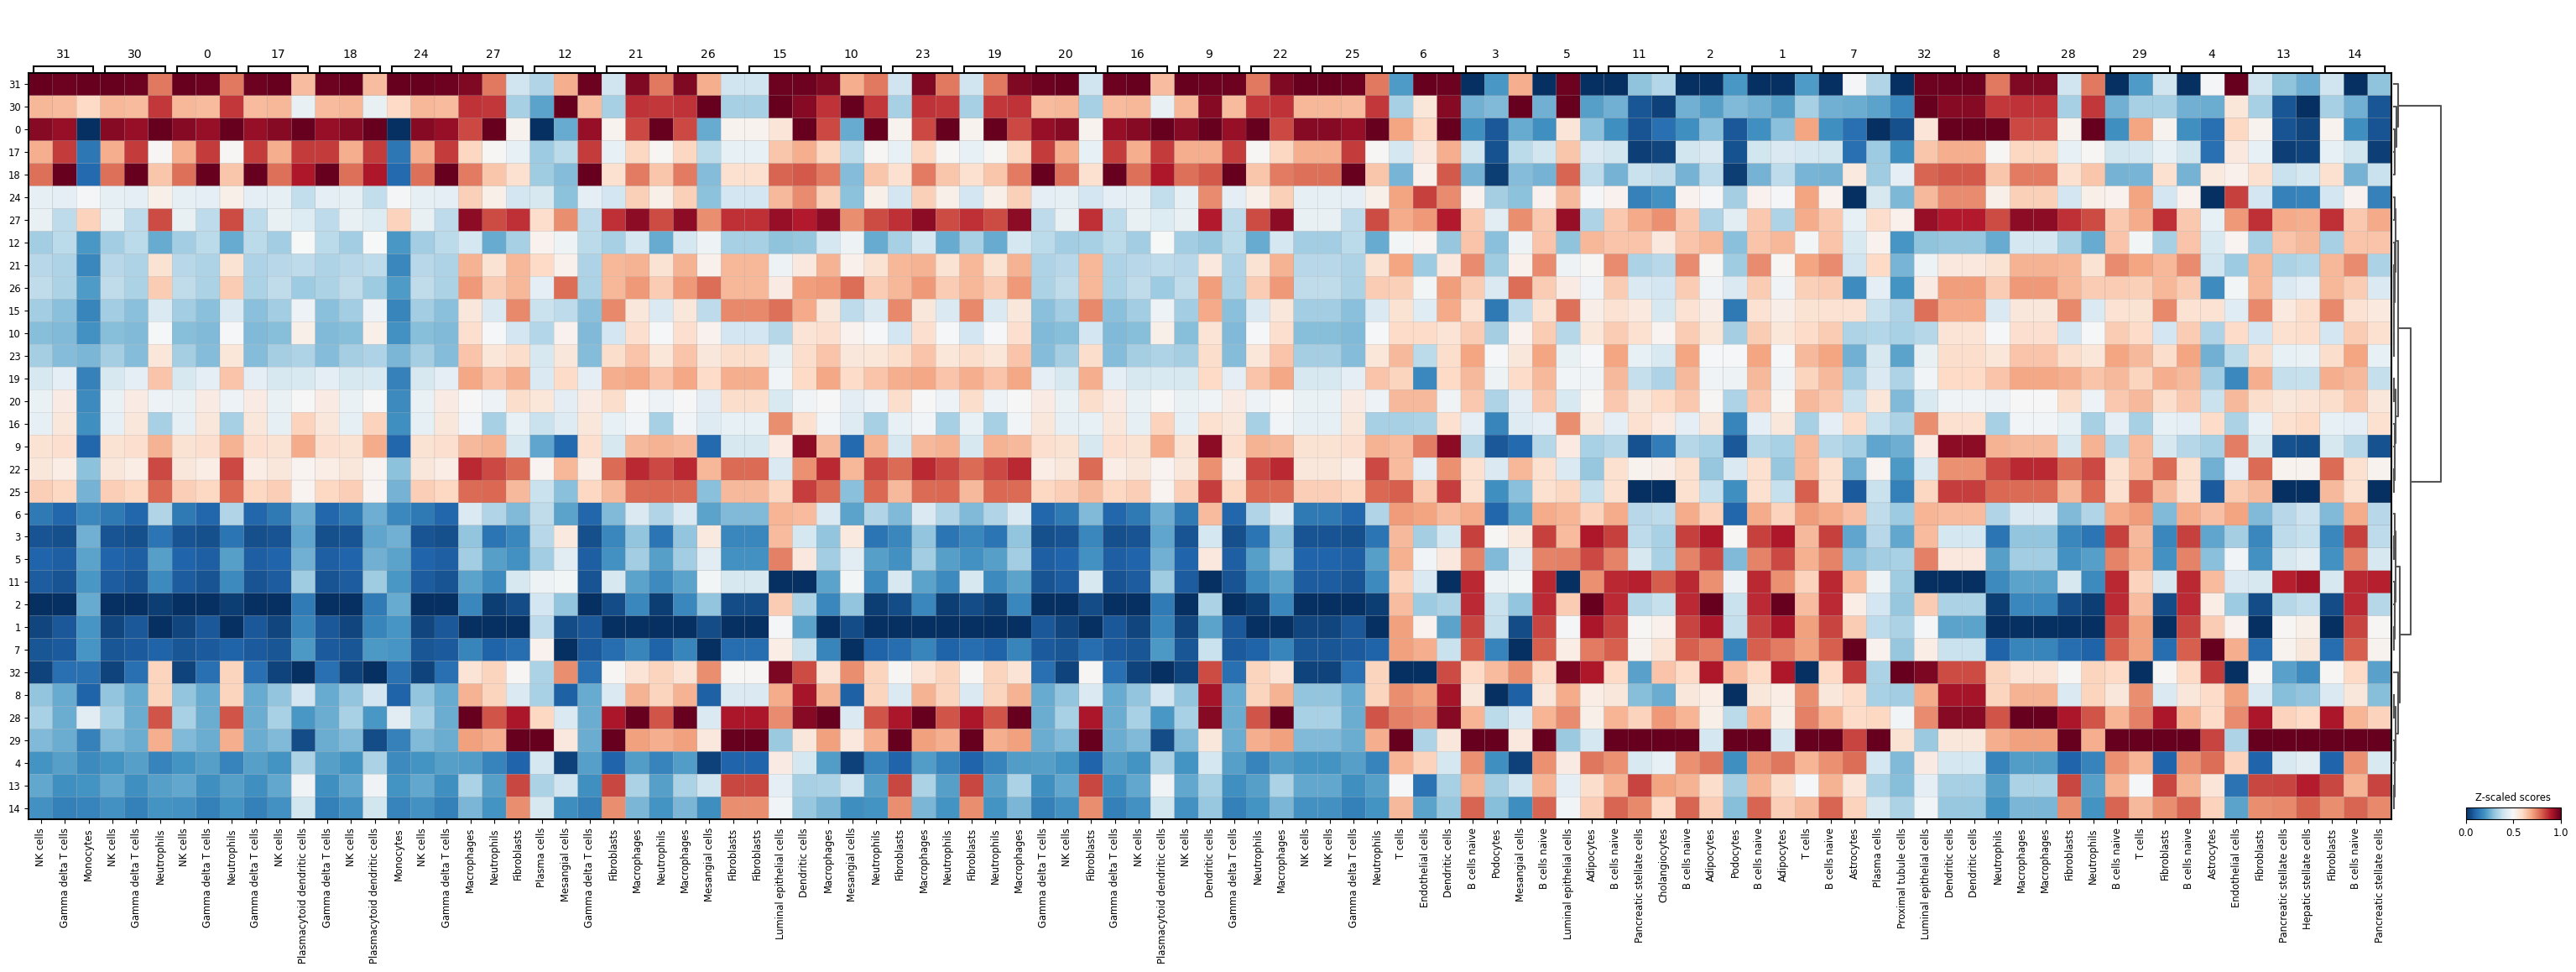

In [80]:
#visualize top predicted cell types can be visualized.
sc.pl.matrixplot(
    adata=score,
    var_names=ctypes_dict,
    groupby="leiden_2",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

## Transcription Factors

In [87]:
#loading in CollecTRI
#a comprehensive resource containing a curated collection of TFs and their transcriptional targets
collectri = dc.op.collectri(organism="human")
collectri

#could also use CellOracle, pySCENIC or SCENIC+.

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


### Scoring

In [88]:
#calculating TF scores
dc.mt.ulm(data=adata, net=collectri)

In [89]:
#extracting the scores
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 450000 × 484
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    uns: 'leiden_2_colors', 'AIFI_L2_colors', 'dendrogram_leiden_2'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'

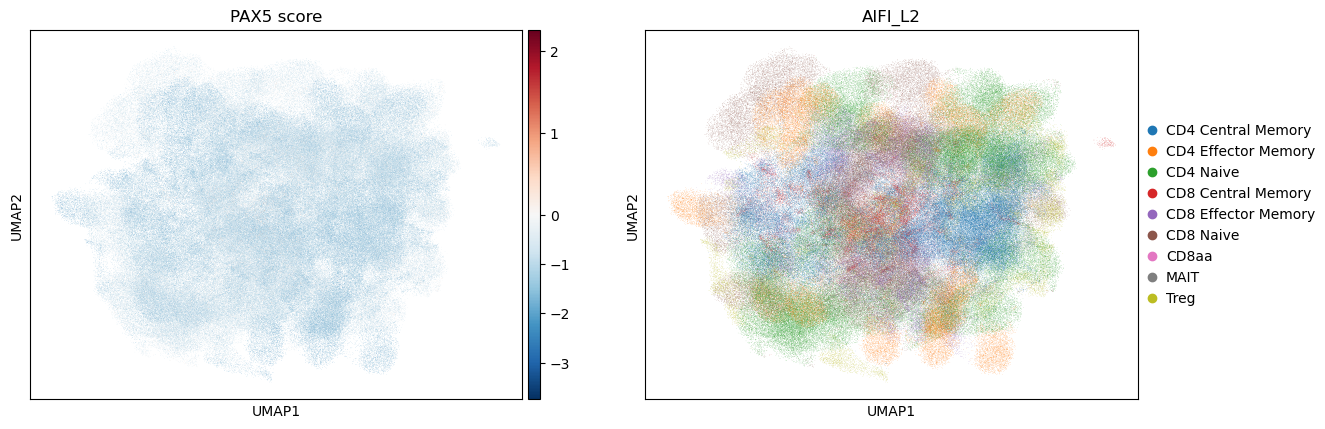

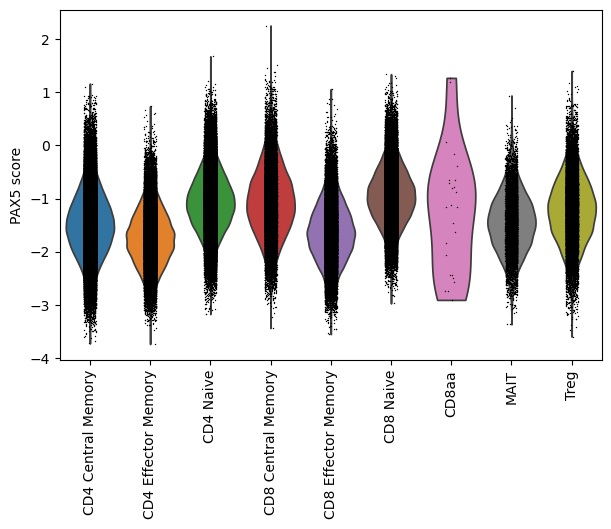

In [93]:
#visualizing
tf = "PAX5"
sc.pl.umap(score, color=[tf, "AIFI_L2"], cmap="RdBu_r", vcenter=0, title=[f"{tf} score", "AIFI_L2"])
sc.pl.violin(score, keys=[tf], groupby="AIFI_L2", rotation=90, ylabel=f"{tf} score")

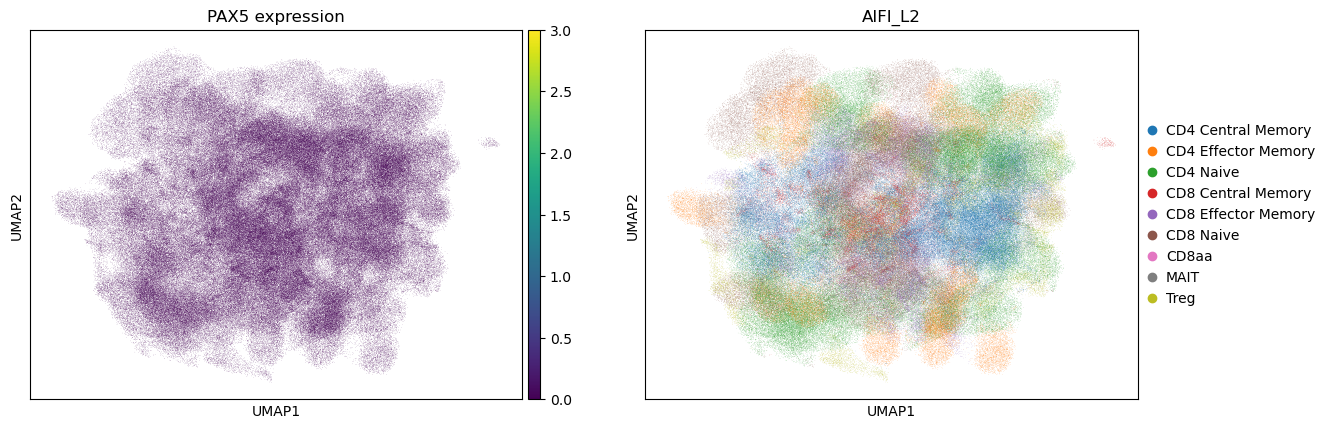

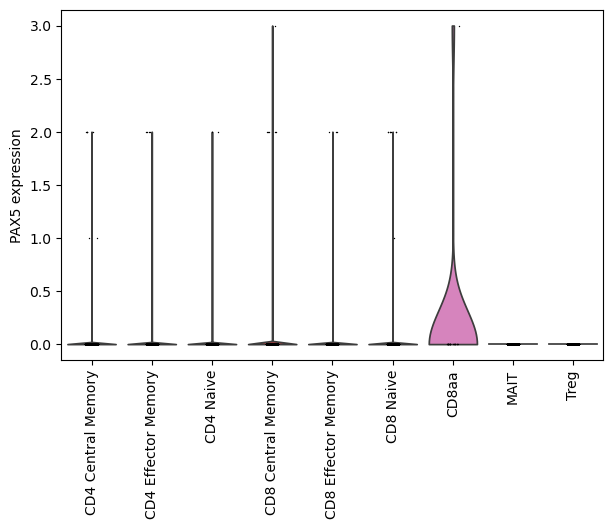

In [94]:
sc.pl.umap(adata, color=[tf, "AIFI_L2"], title=[f"{tf} expression", "AIFI_L2"])
sc.pl.violin(adata, keys=[tf], groupby="AIFI_L2", rotation=90, ylabel=f"{tf} expression")

In [95]:
df = dc.tl.rankby_group(adata=score, groupby="AIFI_L2", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
0,CD4 Central Memory,rest,STAT6,210.478553,0.661391,0.000000,0.000000
1,CD4 Central Memory,rest,RORC,200.096499,0.613680,0.000000,0.000000
2,CD4 Central Memory,rest,ELK1,174.888114,0.725770,0.000000,0.000000
3,CD4 Central Memory,rest,DMTF1,169.659602,0.811687,0.000000,0.000000
4,CD4 Central Memory,rest,SMAD3,166.404984,0.515278,0.000000,0.000000
...,...,...,...,...,...,...,...
4349,CD8aa,rest,FOXA1,0.019974,0.003656,0.984147,0.996224
4350,CD8aa,rest,STAT2,0.017543,0.004713,0.986094,0.996224
4351,CD8aa,rest,NKX3-1,0.010675,0.002487,0.991527,0.996224
4353,CD8aa,rest,NKX2-1,0.009464,0.001436,0.992493,0.996224


In [101]:
#getting top 3 TF markers
source_markers = (
    df.groupby("group")
    .head(3)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

/tmp/ipykernel_97/3837405381.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipykernel_97/3837405381.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["name"]


{'CD4 Central Memory': ['STAT6', 'RORC', 'ELK1'],
 'CD4 Effector Memory': ['SPIC', 'NFKBIB'],
 'CD4 Naive': ['SATB2', 'TCF7L2'],
 'CD8 Central Memory': ['YBX1', 'KLF13'],
 'CD8 Effector Memory': ['RUNX3', 'EOMES', 'TEAD1'],
 'CD8 Naive': ['PATZ1', 'YBX3', 'MZF1'],
 'CD8aa': ['YY1', 'POU2F2', 'NCOA3'],
 'MAIT': ['RARA', 'CEBPB'],
 'Treg': ['TET1', 'MSC', 'BHLHE41']}

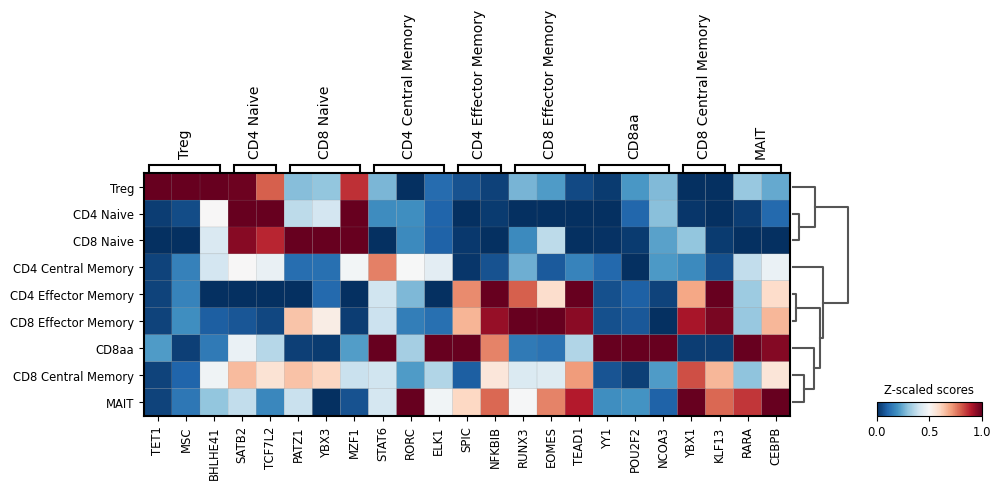

In [103]:
#plotting top 3 TF markers
sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby="AIFI_L2",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

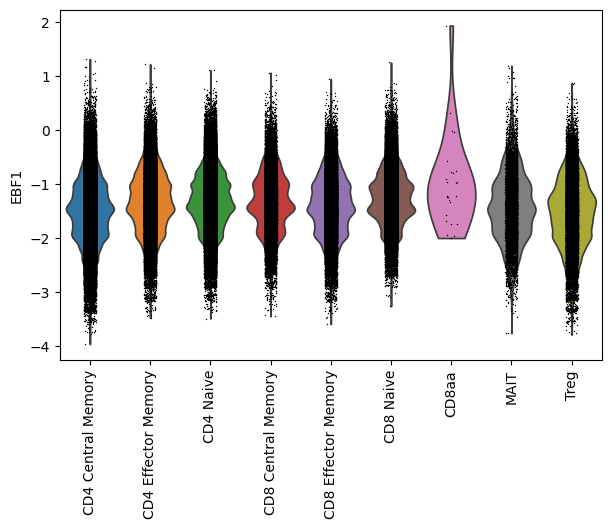

In [105]:
#look at individual TF
sc.pl.violin(score, keys=["EBF1"], groupby="AIFI_L2", rotation=90)

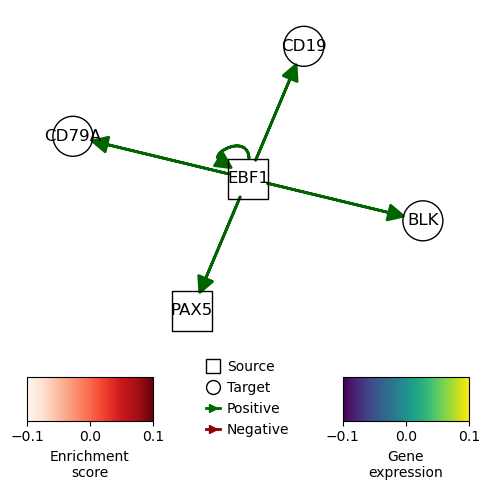

In [106]:
#plot collectri to see relevant TFs and target genes for B cells:

gex_bcells = adata[adata.obs["AIFI_L2"] == "B cells"].to_df().mean(0).to_frame().T
score_bcells = score[score.obs["AIFI_L2"] == "B cells"].to_df().mean(0).to_frame().T

dc.pl.network(
    data=gex_bcells,
    score=score_bcells,
    net=collectri,
    sources=["PAX5", "EBF1", "RFX5"],
    targets=20,
    size_node=10,
    figsize=(5, 5),
    s_cmap="Reds",
)

## Pathway Scoring

Discriptions of the Different pathways:

- Androgen: involved in the growth and development of the male reproductive organs
- EGFR: regulates growth, survival, migration, apoptosis, proliferation, and differentiation in mammalian cells
- Estrogen: promotes the growth and development of the female reproductive organs
- Hypoxia: promotes angiogenesis and metabolic reprogramming when O2 levels are low
- JAK-STAT: involved in immunity, cell division, cell death, and tumor formation
- MAPK: integrates external signals and promotes cell growth and proliferation
- NFkB: regulates immune response, cytokine production and cell survival
- p53: regulates cell cycle, apoptosis, DNA repair and tumor suppression
- PI3K: promotes growth and proliferation
- TGFb: involved in development, homeostasis, and repair of most tissues
- TNFa: mediates haematopoiesis, immune surveillance, tumour regression and protection from infection
- Trail: induces apoptosis
- VEGF: mediates angiogenesis, vascular permeability, and cell migration
- WNT: regulates organ morphogenesis during development and tissue repair

In [108]:
#accessing progeny
#a comprehensive resource that provides a collection of pathways and their target genes
#and weights for each interaction
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


### Scoring

In [109]:
#computing pathway scores
dc.mt.ulm(data=adata, net=progeny)

In [1]:
#extract scores
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

NameError: name 'dc' is not defined

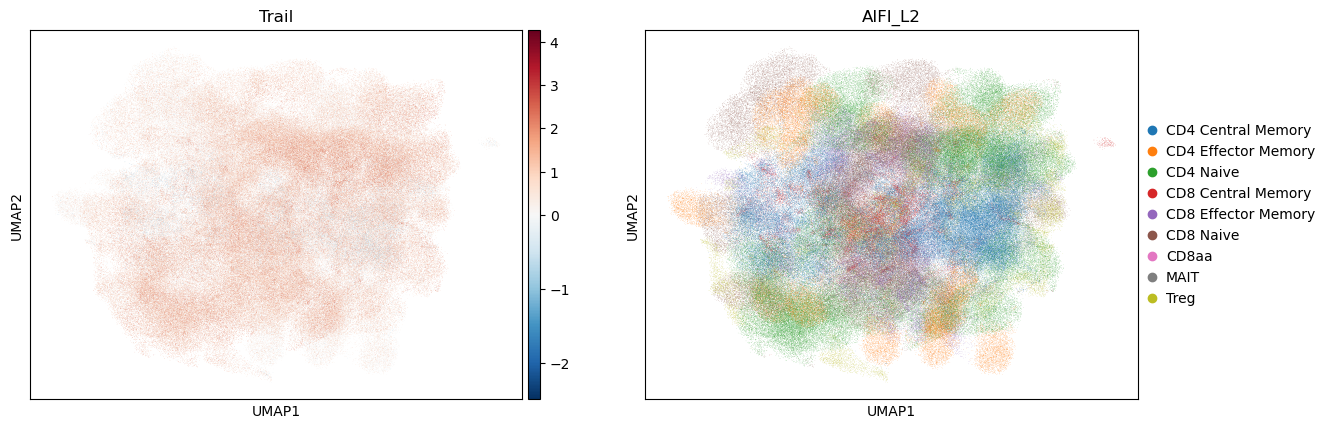

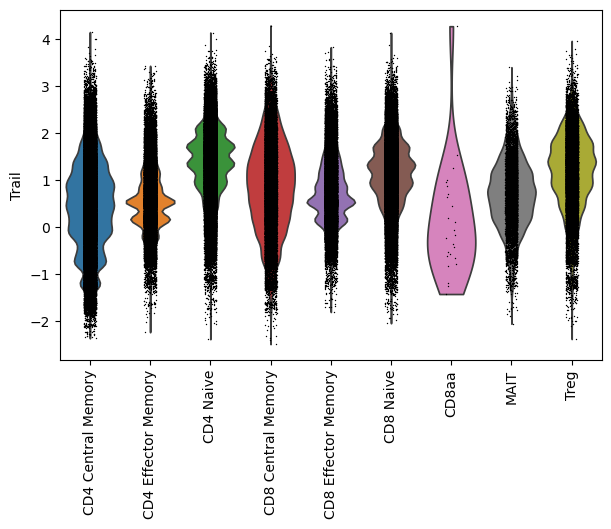

In [111]:
#visualized
sc.pl.umap(score, color=["Trail", "AIFI_L2"], cmap="RdBu_r", vcenter=0)
sc.pl.violin(score, keys=["Trail"], groupby="AIFI_L2", rotation=90)

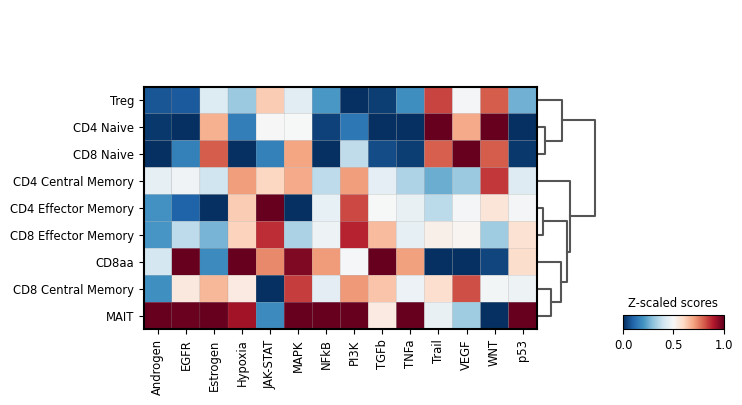

In [113]:
sc.pl.matrixplot(
    adata=score,
    var_names=score.var_names,
    groupby="AIFI_L2",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

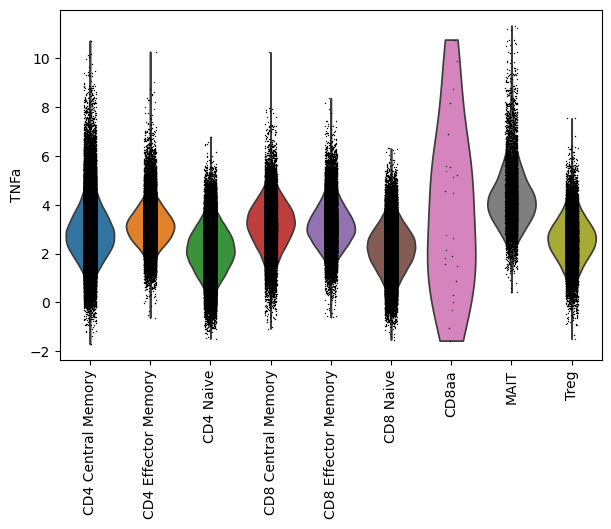

In [116]:
sc.pl.violin(score, keys=["TNFa"], groupby="AIFI_L2", rotation=90)

## Hallmark Gene Sets

Hallmark gene sets are curated collections of genes that represent specific, well-defined biological states or processes. They are part of MSigDB and were developed to reduce redundancy and improve interpretability compared to older, more overlapping gene set collections

In [117]:
#accessing it
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


### Scoring

In [118]:
#calculating pathway scores
dc.mt.ulm(data=adata, net=hallmark)

In [119]:
#extracting scores
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 450000 × 50
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    uns: 'leiden_2_colors', 'AIFI_L2_colors', 'dendrogram_leiden_2', 'dendrogram_AIFI_L2'
    obsm: 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'

In [120]:
#identify marker gene sets for each cell type
df = dc.tl.rankby_group(adata=score, groupby="AIFI_L2", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
0,CD4 Central Memory,rest,HYPOXIA,248.651573,1.332163,0.000000,0.000000
1,CD4 Central Memory,rest,ANDROGEN_RESPONSE,154.225170,0.556558,0.000000,0.000000
2,CD4 Central Memory,rest,P53_PATHWAY,152.494662,0.617224,0.000000,0.000000
3,CD4 Central Memory,rest,MTORC1_SIGNALING,140.077111,0.562168,0.000000,0.000000
4,CD4 Central Memory,rest,APOPTOSIS,115.484324,0.466754,0.000000,0.000000
...,...,...,...,...,...,...,...
442,CD8aa,rest,NOTCH_SIGNALING,0.634653,0.117956,0.528761,0.614839
444,CD8aa,rest,APICAL_JUNCTION,0.433250,0.086983,0.666786,0.740873
447,CD8aa,rest,ADIPOGENESIS,0.104187,0.025125,0.917466,0.938833
448,CD8aa,rest,INTERFERON_ALPHA_RESPONSE,0.101045,0.042432,0.920056,0.938833


In [121]:
#getting top 3 markers per cell type
source_markers = (
    df.groupby("group")
    .head(3)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

/tmp/ipykernel_97/224451901.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipykernel_97/224451901.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["name"]


{'CD4 Central Memory': ['HYPOXIA', 'ANDROGEN_RESPONSE', 'P53_PATHWAY'],
 'CD4 Effector Memory': ['EPITHELIAL_MESENCHYMAL_TRANSITION'],
 'CD4 Naive': ['APICAL_JUNCTION', 'PANCREAS_BETA_CELLS'],
 'CD8 Central Memory': ['TNFA_SIGNALING_VIA_NFKB', 'CHOLESTEROL_HOMEOSTASIS'],
 'CD8 Effector Memory': ['ALLOGRAFT_REJECTION',
  'COMPLEMENT',
  'INTERFERON_GAMMA_RESPONSE'],
 'CD8 Naive': ['WNT_BETA_CATENIN_SIGNALING', 'MYC_TARGETS_V1', 'DNA_REPAIR'],
 'CD8aa': ['HEDGEHOG_SIGNALING', 'KRAS_SIGNALING_UP'],
 'MAIT': [],
 'Treg': ['IL2_STAT5_SIGNALING',
  'IL6_JAK_STAT3_SIGNALING',
  'ESTROGEN_RESPONSE_LATE']}

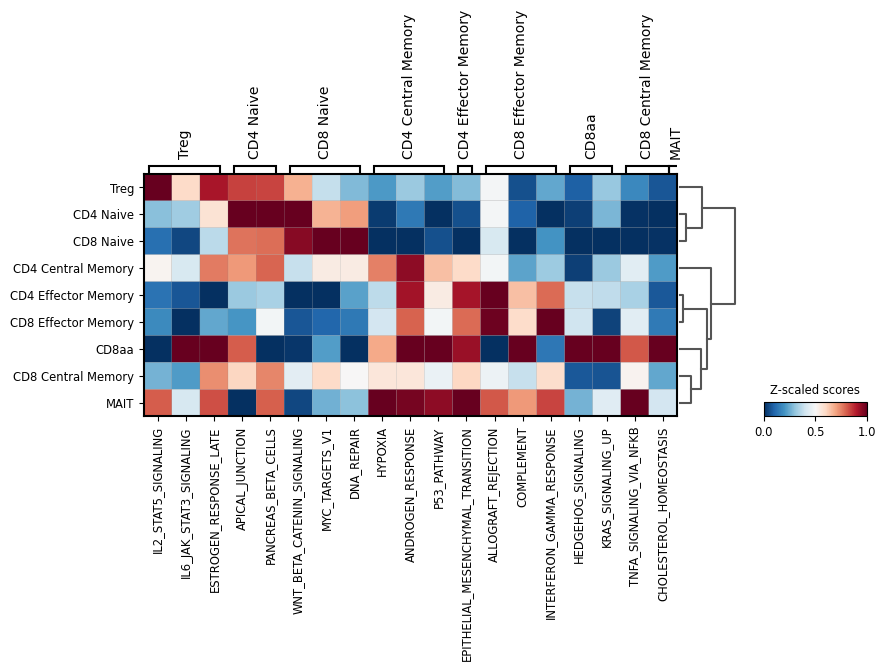

In [123]:
#visualized 
sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby="AIFI_L2",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)